## Example Exam Questions Chapter 4

In [2]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1
Criminologists have long debated whether there is a relationship between weather conditions and the number of crimes committed. In 1988, an article “Is there a
Season for Homicide?” (Criminology, 1988: 287-296) classified 1361 homicides by season, resulting
in the data below.  
Is there an association between season and the number of murders committed?


H0: There is no association between season and amount of homicides  
H1: There is an association between season and amount of homicides

<Axes: >

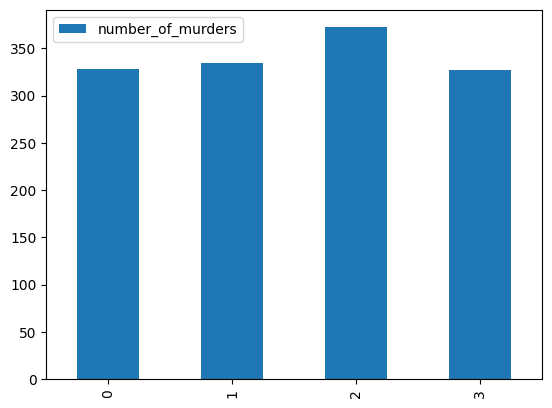

In [5]:
dfmurders = pd.DataFrame(data={
    'season': ['winter', 'spring','summer','autumn'],
    'number_of_murders': [328, 334, 372, 327]
})

dfmurders.plot(kind='bar')

In [15]:
n = dfmurders['number_of_murders'].sum()
alpha = 0.05

observed = dfmurders['number_of_murders']
expected = np.repeat(n / 4, 4)

dof = len(observed) - 1

chi2, p = stats.chisquare(observed, expected)
g = stats.chi2.isf(alpha, df=dof)

print(round(chi2, 3))
print(round(p, 3))
print(round(g, 3))

4.035
0.258
7.815


p > alpha and chi2 < g so we do not reject H0. This sample does not show a significant association between season and number of homicides

## Exercise 2
A random sample of individuals was taken, and each individual was classified according to their level of education and their sense of spirituality.
Is there an association between the level of education and the sense of spirituality?

H0: There is no association between spirituality and level of education  
H1: There is an association between spirituality and level of education

In [16]:
dfspirituality = pd.DataFrame(data={
    'sense_of_spirituality': ['lot', 'moderate','little','none'],
    'alfa_scientist': [56, 162, 198, 211],
    'beta_scientist': [56, 223, 243, 239],
    'not_scientist': [109, 164, 74, 28]
})
dfspirituality.head()

,sense_of_spirituality,alfa_scientist,beta_scientist,not_scientist
0,lot,56,56,109
1,moderate,162,223,164
2,little,198,243,74
3,none,211,239,28


In [19]:
alpha = 0.05
dfspirituality = dfspirituality.drop('sense_of_spirituality', axis=1)

chi2, p, dof, expected = stats.chi2_contingency(dfspirituality)
g = stats.chi2.isf(alpha, df=dof)

print(round(chi2, 3))
print(round(p, 3))
print(round(g, 3))

213.212
0.0
12.592


p < alpha and chi2 > g. There is a strong association between spirituality and level of education.

In [38]:
v = stats.contingency.association(dfspirituality, method='cramer')
v

0.24590359045026888

## Exercise 4

In an experiment, 150 patients were divided into three groups of 45, 45 and 60 patients each. Two groups were given a new drug in different doses and the third group was given a placebo. The way the patients felt after using the drug are shown in the data frame below. Is there evidence at the 5% significance level that there is a difference in the condition between the three groups of patients?



H0: There is no association between the drugs and the state of the patient  
H1: There is an association between the drugs and the state of the patient

In [35]:
dfexperiment = pd.DataFrame(data={
    'state': ['better', 'equal', 'worse'],
    'placebo': [16, 20, 9],
    'half_dosis': [17, 18, 10],
    'full_dosis': [26, 20, 14]
}).set_index('state')
dfexperiment.head()

,placebo,half_dosis,full_dosis
state,,,
better,16,17,26
equal,20,18,20
worse,9,10,14


In [37]:
alpha = 0.05

chi2, p, dof, expected = stats.chi2_contingency(dfexperiment)
g = stats.chi2.isf(alpha, dof)

print(round(chi2, 3))
print(round(p, 3))
print(round(g, 3))

1.417
0.841
9.488


p > alpha and chi2 < g.  
There is no association between the amount of the drug and the state of the patients. We do not reject H0

In [39]:
v = stats.contingency.association(dfexperiment, method='cramer')
v

0.06872447629349096